# Visualizaciones e-Visor — Indicadores y KPIs

Materializa cada visualización aprobada en la fase A2.3.

**Estructura:**
- Celda 1: carga de `indicadores_diarios.csv` y configuración común.
- Celdas 2–12: una visualización por indicador (LF, PAR, f1, f2, f3, f4, HU, CO2, desbalance, FP, THD-V).
- Celda 13: carga de `kpis_diarios.csv`.
- Celdas 14–21: una visualización por KPI (03, 05, 08, 09, 10, 11, 12) + un KPI 01 ilustrativo.

Indicadores no incluidos por falta de fuente de datos en estos archivos: IGS, TCP, EB, Ahorro (ver código de cálculo).

In [1]:
# ── Celda 1: Carga indicadores y configuración común ─────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

RUTA_INDICADORES = 'indicadores_diarios.csv'
RUTA_KPIS        = 'kpis_diarios.csv'

ind = pd.read_csv(RUTA_INDICADORES)
ind['fecha'] = pd.to_datetime(ind['fecha'])

# Estilo común mínimo y consistente con la propuesta visual
plt.rcParams.update({
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.titleweight':'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':       False,
})

# Paleta
C_TEAL  = '#1D9E75'
C_AMBER = '#EF9F27'
C_RED   = '#A32D2D'
C_GRAY  = '#B4B2A9'
C_BLUE  = '#378ADD'
C_PURPLE= '#534AB7'

print(f'Indicadores cargados: {len(ind):,} filas · {ind["entity_id"].nunique()} medidores')
ind.head()

Indicadores cargados: 465 filas · 15 medidores


,entity_id,fecha,LF,PAR,f1,f2_CV,f3,f4,HU_horas,CO2_tCO2e,desbalance_pct,fp_promedio,thd_v_pct
0,SmartMeter_SM_B10_ARQ,2026-02-10,0.616194,1.622866,0.780387,0.213267,0.561767,0.555894,0.014499,0.029602,0.590018,0.948333,2.487369
1,SmartMeter_SM_B10_ARQ,2026-02-11,0.496221,2.015233,0.633413,0.390590,0.504865,0.539210,0.011528,0.044054,0.673316,0.925475,2.351624
2,SmartMeter_SM_B10_ARQ,2026-02-12,0.658580,1.518419,0.638510,0.226081,0.583932,1.050790,0.015286,0.043069,0.589177,0.932982,2.435472
3,SmartMeter_SM_B10_ARQ,2026-02-13,0.375208,2.665189,0.477707,0.388648,0.436378,0.544701,0.008812,0.028455,0.504226,0.936988,2.299417
4,SmartMeter_SM_B10_ARQ,2026-02-14,0.627169,1.594467,0.690834,0.298014,0.563126,0.830813,0.014603,0.014544,0.395151,0.922160,1.748917


In [ ]:
# ── Celda 2: Indicador LF — Barras horizontales por bloque + evolución diaria ─
lf_bloque = ind.groupby('entity_id')['LF'].mean().sort_values()
REF_LF = 0.65
colores = [C_TEAL if v >= REF_LF else C_AMBER for v in lf_bloque]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(lf_bloque))))
ax.barh(lf_bloque.index.astype(str), lf_bloque.values, color=colores, edgecolor='none')
ax.axvline(REF_LF, color='#5F5E5A', linestyle='--', linewidth=1)
ax.text(REF_LF, len(lf_bloque) - 0.4, f' LF = {REF_LF} (ref.)',
        ha='left', va='bottom', fontsize=10, color='#5F5E5A')
for i, v in enumerate(lf_bloque.values):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
ax.set_xlim(0, max(1.0, lf_bloque.max() * 1.15))
ax.set_title('LF por bloque (promedio del período)', loc='left')
ax.set_xlabel('0 = picos extremos · 1 = consumo plano')
plt.tight_layout()
plt.show()

# Serie temporal diaria — campus promedio
_serie_lf = ind.groupby('fecha')['LF'].mean().sort_index()
_laboral   = _serie_lf[_serie_lf.index.dayofweek < 5]
_finde     = _serie_lf[_serie_lf.index.dayofweek >= 5]
_ma7       = _serie_lf.rolling(7, min_periods=1).mean()

fig2, ax2 = plt.subplots(figsize=(11, 3.5))
ax2.plot(_laboral.index, _laboral.values, color=C_TEAL, linewidth=1.5,
         marker='o', markersize=4, label='Día hábil (L–V)')
ax2.scatter(_finde.index, _finde.values, color=C_AMBER, s=40,
            marker='D', zorder=5, label='Fin de semana (S–D)')
ax2.plot(_serie_lf.index, _ma7.values, color=C_GRAY, linewidth=2,
         linestyle=':', label='Media móvil 7 días')
ax2.axhline(REF_LF, color='#5F5E5A', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('Evolución diaria del LF (campus promedio)', loc='left')
ax2.set_ylabel('LF (adimensional)')
ax2.set_ylim(bottom=0)
ax2.legend(frameon=False, fontsize=10, loc='upper right')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
fig2.autofmt_xdate()
plt.tight_layout()
plt.show()

In [3]:
# ── Celda 3: Indicador PAR — Tabla por bloque (lectura técnica auxiliar) ─────
par_bloque = (ind.groupby('entity_id')['PAR'].mean()
                .sort_values(ascending=False)
                .round(2)
                .to_frame('PAR'))
par_bloque['Lectura'] = par_bloque['PAR'].apply(
    lambda v: f'El pico es ~{v:.1f}× el promedio'
)
par_bloque.index.name = 'Bloque'
par_bloque

,PAR,Lectura
Bloque,,
SmartMeter_SM_B8_AA,3.41,El pico es ~3.4× el promedio
SmartMeter_SM_B8_CPA,2.28,El pico es ~2.3× el promedio
SmartMeter_SM_B3_RECT,1.92,El pico es ~1.9× el promedio
SmartMeter_SM_B10_ARQ,1.91,El pico es ~1.9× el promedio
SmartMeter_SM_B9_SFA2,1.90,El pico es ~1.9× el promedio
SmartMeter_SM_B5_BACH,1.87,El pico es ~1.9× el promedio
SmartMeter_SM_B7_TAC,1.86,El pico es ~1.9× el promedio
SmartMeter_SM_B12_DERE,1.83,El pico es ~1.8× el promedio
SmartMeter_SM_B17_POLI,1.77,El pico es ~1.8× el promedio


In [ ]:
# ── Celda 4: Helpers compartidos f₁–f₄ + Indicador f₁ —————————————————————
import plotly.graph_objects as go
from plotly.subplots import make_subplots

HORA_OP_INI = 6   # franja operacional 06:00–21:59
HORA_OP_FIN = 22


def calcular_componentes_diurnos(df):
    """Retorna dict {perfil, prom, max, min, std} de la franja operacional del df dado."""
    d = df.copy()
    d['hora'] = pd.to_datetime(d['time_index_colombia']).dt.hour
    mask_op   = (d['hora'] >= HORA_OP_INI) & (d['hora'] < HORA_OP_FIN)
    ap_op     = d[mask_op]['activepower'].dropna()
    perfil    = d[mask_op].groupby('hora')['activepower'].mean()
    if ap_op.empty:
        return None
    return {
        'perfil': perfil,
        'prom': float(ap_op.mean()),
        'max':  float(ap_op.max()),
        'min':  float(ap_op.min()),
        'std':  float(ap_op.std()),
    }


def _delta_semana(ind_df, col):
    """(delta, ref_val, fecha_ref) vs mismo día semana anterior. None si no hay referencia."""
    serie = ind_df.groupby('fecha')[col].mean().sort_index()
    if serie.empty:
        return None, None, None
    fecha_hoy  = serie.index[-1]
    candidatos = serie[(serie.index.dayofweek == fecha_hoy.dayofweek) &
                       (serie.index < fecha_hoy)]
    if candidatos.empty:
        return None, None, None
    return float(serie.iloc[-1]) - float(candidatos.iloc[-1]), float(candidatos.iloc[-1]), candidatos.index[-1]


def graficar_card(valor, num_lbl, num_val, den_lbl, den_val,
                  delta, ref_val, fecha_ref, fecha_hoy):
    """Widget 1 genérico: valor grande + componentes + delta semanal."""
    ind_kw = dict(
        mode='number+delta' if delta is not None else 'number',
        value=round(float(valor), 3),
        number=dict(font=dict(size=64, color='#2C2C2A'), valueformat='.3f'),
        domain=dict(x=[0.1, 0.9], y=[0.45, 1.0]),
    )
    if delta is not None:
        ind_kw['delta'] = dict(
            reference=round(float(ref_val), 3), valueformat='.3f', relative=False,
            increasing=dict(color=C_AMBER), decreasing=dict(color=C_TEAL),
        )
    fig = go.Figure(go.Indicator(**ind_kw))
    if num_val is not None and den_val is not None:
        fig.add_annotation(
            x=0.5, y=0.28, xref='paper', yref='paper', showarrow=False,
            text=(f'<b>{num_lbl}:</b> {num_val:.0f} W'
                  f'&nbsp;&nbsp;&nbsp;&nbsp;'
                  f'<b>{den_lbl}:</b> {den_val:.0f} W'),
            font=dict(size=14, color='#5F5E5A'), align='center',
        )
    if delta is not None:
        flecha = '↑' if delta > 0 else '↓'
        fig.add_annotation(
            x=0.5, y=0.10, xref='paper', yref='paper', showarrow=False,
            text=(f'{flecha} {abs(delta):.3f} respecto al '
                  f'{fecha_ref.strftime("%d %b")} (mismo día semana anterior)'),
            font=dict(size=13, color=C_AMBER if delta > 0 else C_TEAL), align='center',
        )
    else:
        fig.add_annotation(
            x=0.5, y=0.10, xref='paper', yref='paper', showarrow=False,
            text='Sin referencia de la semana anterior',
            font=dict(size=12, color=C_GRAY),
        )
    fig.update_layout(
        title=dict(text=f'Valor más reciente — {fecha_hoy.strftime("%d %b %Y")}',
                   font=dict(size=13), x=0.5, xanchor='center'),
        plot_bgcolor='white', paper_bgcolor='white',
        height=260, margin=dict(t=40, b=10, l=20, r=20),
    )
    return fig


def graficar_serie_diaria(ind_df, col, titulo_y):
    """Widget 2 genérico: serie diaria con diferenciación hábil/finde y MA7."""
    serie = ind_df.groupby('fecha')[col].mean().sort_index()
    if serie.empty:
        return go.Figure()
    df_s = serie.rename('val').to_frame()
    df_s['es_finde'] = df_s.index.dayofweek >= 5
    df_s['ma7']      = df_s['val'].rolling(7, min_periods=1).mean()
    laboral = df_s[~df_s['es_finde']]
    finde   = df_s[df_s['es_finde']]
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=laboral.index, y=laboral['val'], mode='lines+markers',
        name='Día hábil (L–V)',
        line=dict(color=C_TEAL, width=1.5), marker=dict(color=C_TEAL, size=5),
    ))
    fig.add_trace(go.Scatter(
        x=finde.index, y=finde['val'], mode='markers',
        name='Fin de semana (S–D)',
        marker=dict(color=C_AMBER, size=7, symbol='diamond'),
    ))
    fig.add_trace(go.Scatter(
        x=df_s.index, y=df_s['ma7'], mode='lines',
        name='Media móvil 7 días',
        line=dict(color=C_GRAY, width=2.5, dash='dot'), opacity=0.75,
    ))
    fig.update_layout(
        title=dict(text='Evolución diaria', font=dict(size=13), x=0, xanchor='left'),
        xaxis_title='Fecha', yaxis_title=titulo_y,
        legend=dict(orientation='h', yanchor='bottom', y=1.02,
                    xanchor='right', x=1, font=dict(size=11)),
        plot_bgcolor='white', paper_bgcolor='white',
        height=320, margin=dict(t=60, b=40, l=60, r=20),
        xaxis=dict(gridcolor='#EEEEEE'),
        yaxis=dict(gridcolor='#EEEEEE', rangemode='tozero'),
    )
    return fig


def graficar_comparativo_bloques(ind_df, col, titulo_x):
    """Barras horizontales de un indicador por bloque (comparativo del período)."""
    serie = (ind_df
             .assign(bloque=ind_df['entity_id'].str.replace('SmartMeter_SM_', '', regex=False))
             .groupby('bloque')[col].mean()
             .sort_values())
    fig = go.Figure(go.Bar(
        x=serie.values, y=serie.index.tolist(),
        orientation='h', marker_color=C_BLUE,
        text=[f'{v:.3f}' for v in serie.values], textposition='outside',
    ))
    fig.update_layout(
        title=dict(text='Comparativo por bloque (promedio del período)',
                   font=dict(size=13), x=0, xanchor='left'),
        xaxis_title=titulo_x,
        plot_bgcolor='white', paper_bgcolor='white',
        height=max(280, 30 * len(serie) + 100),
        margin=dict(t=40, b=40, l=110, r=80),
        xaxis=dict(gridcolor='#EEEEEE'),
    )
    return fig


def _base_perfil_layout(fig):
    fig.update_xaxes(title='Hora del día',
                     tickvals=list(range(6, 22, 2)),
                     ticktext=[f'{h:02d}:00' for h in range(6, 22, 2)])
    fig.update_yaxes(title='Potencia activa (W)', gridcolor='#EEEEEE')
    fig.update_layout(
        title=dict(text='Perfil diurno — evidencia del cálculo',
                   font=dict(size=13), x=0, xanchor='left'),
        plot_bgcolor='white', paper_bgcolor='white',
        height=320, margin=dict(t=40, b=50, l=60, r=120),
        xaxis=dict(gridcolor='#EEEEEE'),
    )
    return fig


def graficar_evidencia_f1(comp):
    """Perfil con P̄ (num.) y P_max (den.) anotados."""
    fig = go.Figure()
    if comp is None:
        fig.add_annotation(x=0.5, y=0.5, text='Datos crudos no disponibles',
                           xref='paper', yref='paper', showarrow=False)
        return fig
    p = comp['perfil']
    fig.add_trace(go.Scatter(x=p.index, y=p.values, mode='lines+markers',
                              showlegend=False,
                              line=dict(color=C_TEAL, width=2),
                              marker=dict(color=C_TEAL, size=5)))
    fig.add_hline(y=comp['prom'], line=dict(color=C_AMBER, width=1.5, dash='dash'))
    fig.add_annotation(x=p.index[-1], y=comp['prom'], xref='x', yref='y',
                       text=f'P̄ = {comp["prom"]:.0f} W (num.)',
                       showarrow=False, xanchor='right', yanchor='bottom',
                       font=dict(size=11, color=C_AMBER))
    fig.add_hline(y=comp['max'], line=dict(color=C_PURPLE, width=1.5, dash='dash'))
    fig.add_annotation(x=p.index[-1], y=comp['max'], xref='x', yref='y',
                       text=f'P_max = {comp["max"]:.0f} W (den.)',
                       showarrow=False, xanchor='right', yanchor='top',
                       font=dict(size=11, color=C_PURPLE))
    return _base_perfil_layout(fig)


def graficar_evidencia_f2(comp):
    """Perfil con banda ±σ (num.) y P̄ (den.) anotados."""
    fig = go.Figure()
    if comp is None:
        fig.add_annotation(x=0.5, y=0.5, text='Datos crudos no disponibles',
                           xref='paper', yref='paper', showarrow=False)
        return fig
    p = comp['perfil']
    xs = list(p.index) + list(p.index[::-1])
    ys = ([comp['prom'] + comp['std']] * len(p) +
          [comp['prom'] - comp['std']] * len(p))
    fig.add_trace(go.Scatter(x=xs, y=ys, fill='toself',
                              fillcolor='rgba(55,138,221,0.15)',
                              line=dict(color='rgba(0,0,0,0)'),
                              name=f'±σ = {comp["std"]:.0f} W (num.)'))
    fig.add_trace(go.Scatter(x=p.index, y=p.values, mode='lines+markers',
                              showlegend=False,
                              line=dict(color=C_TEAL, width=2),
                              marker=dict(color=C_TEAL, size=5)))
    fig.add_hline(y=comp['prom'], line=dict(color=C_AMBER, width=1.5, dash='dash'))
    fig.add_annotation(x=p.index[-1], y=comp['prom'], xref='x', yref='y',
                       text=f'P̄ = {comp["prom"]:.0f} W (den.)',
                       showarrow=False, xanchor='right', yanchor='bottom',
                       font=dict(size=11, color=C_AMBER))
    fig = _base_perfil_layout(fig)
    fig.update_layout(legend=dict(orientation='h', y=1.05, x=0, font=dict(size=10)))
    return fig


def graficar_evidencia_f3(comp):
    """Perfil con P_min (num.) y P̄ (den.) anotados."""
    fig = go.Figure()
    if comp is None:
        fig.add_annotation(x=0.5, y=0.5, text='Datos crudos no disponibles',
                           xref='paper', yref='paper', showarrow=False)
        return fig
    p = comp['perfil']
    h_min = p.idxmin()
    fig.add_trace(go.Scatter(x=p.index, y=p.values, mode='lines+markers',
                              showlegend=False,
                              line=dict(color=C_TEAL, width=2),
                              marker=dict(color=C_TEAL, size=5)))
    fig.add_trace(go.Scatter(x=[h_min], y=[comp['min']], mode='markers',
                              name=f'P_min = {comp["min"]:.0f} W (num.)',
                              marker=dict(color=C_RED, size=10)))
    fig.add_hline(y=comp['prom'], line=dict(color=C_AMBER, width=1.5, dash='dash'))
    fig.add_annotation(x=p.index[-1], y=comp['prom'], xref='x', yref='y',
                       text=f'P̄ = {comp["prom"]:.0f} W (den.)',
                       showarrow=False, xanchor='right', yanchor='bottom',
                       font=dict(size=11, color=C_AMBER))
    fig.add_annotation(x=h_min, y=comp['min'], xref='x', yref='y',
                       text=f'P_min = {comp["min"]:.0f} W (num.)',
                       showarrow=False, xanchor='center', yanchor='top',
                       font=dict(size=11, color=C_RED))
    fig = _base_perfil_layout(fig)
    fig.update_layout(legend=dict(orientation='h', y=1.05, x=0, font=dict(size=10)))
    return fig


# ── Renderizar f₁ ——————————————————————————————————————————————————————————————————————————
try:
    data_raw = pd.read_csv('etsmartmeter_clean.csv', parse_dates=['time_index_colombia'])
    data_raw['_fecha'] = data_raw['time_index_colombia'].dt.normalize()
    fecha_max_raw = data_raw['_fecha'].max()
    comp_f1 = calcular_componentes_diurnos(data_raw[data_raw['_fecha'] == fecha_max_raw])
except FileNotFoundError:
    comp_f1 = None
    data_raw = None

delta, ref_val, fecha_ref = _delta_semana(ind, 'f1')
fecha_hoy = ind['fecha'].max()
valor_f1  = ind[ind['fecha'] == fecha_hoy]['f1'].mean()

graficar_card(
    valor_f1,
    'P̄ operacional', comp_f1['prom'] if comp_f1 else None,
    'P_max operacional', comp_f1['max'] if comp_f1 else None,
    delta, ref_val, fecha_ref, fecha_hoy,
).show()
graficar_serie_diaria(ind, 'f1', 'f₁ (adimensional)').show()
graficar_evidencia_f1(comp_f1).show()
graficar_comparativo_bloques(ind, 'f1', 'f₁ (adimensional)').show()


In [ ]:
# ── Celda 5: Indicador f₂ ——————————————————————————————————————————————————————————————————————————————————
try:
    _f2_data = data_raw if data_raw is not None else pd.read_csv('etsmartmeter_clean.csv', parse_dates=['time_index_colombia'])
    _f2_data['_fecha'] = _f2_data['time_index_colombia'].dt.normalize()
    comp_f2 = calcular_componentes_diurnos(_f2_data[_f2_data['_fecha'] == _f2_data['_fecha'].max()])
except (FileNotFoundError, NameError):
    comp_f2 = None

delta, ref_val, fecha_ref = _delta_semana(ind, 'f2_CV')
fecha_hoy = ind['fecha'].max()
valor_f2  = ind[ind['fecha'] == fecha_hoy]['f2_CV'].mean()

graficar_card(
    valor_f2,
    'σ operacional', comp_f2['std'] if comp_f2 else None,
    'P̄ operacional', comp_f2['prom'] if comp_f2 else None,
    delta, ref_val, fecha_ref, fecha_hoy,
).show()
graficar_serie_diaria(ind, 'f2_CV', 'f₂ (CV, adimensional)').show()
graficar_evidencia_f2(comp_f2).show()
graficar_comparativo_bloques(ind, 'f2_CV', 'f₂ (adimensional)').show()


In [ ]:
# ── Celda 6: Indicador f₃ ——————————————————————————————————————————————————————————————————————————————————
try:
    _f3_data = data_raw if data_raw is not None else pd.read_csv('etsmartmeter_clean.csv', parse_dates=['time_index_colombia'])
    _f3_data['_fecha'] = _f3_data['time_index_colombia'].dt.normalize()
    comp_f3 = calcular_componentes_diurnos(_f3_data[_f3_data['_fecha'] == _f3_data['_fecha'].max()])
except (FileNotFoundError, NameError):
    comp_f3 = None

delta, ref_val, fecha_ref = _delta_semana(ind, 'f3')
fecha_hoy = ind['fecha'].max()
valor_f3  = ind[ind['fecha'] == fecha_hoy]['f3'].mean()

graficar_card(
    valor_f3,
    'P_min operacional', comp_f3['min'] if comp_f3 else None,
    'P̄ operacional',  comp_f3['prom'] if comp_f3 else None,
    delta, ref_val, fecha_ref, fecha_hoy,
).show()
graficar_serie_diaria(ind, 'f3', 'f₃ (adimensional)').show()
graficar_evidencia_f3(comp_f3).show()
graficar_comparativo_bloques(ind, 'f3', 'f₃ (adimensional)').show()


In [ ]:
# ── Celda 7: Indicador f₄ — Tres widgets apilados (Plotly) ──────────────────
import plotly.graph_objects as go

HORA_INICIO_OPERACION = 6   # operación 06:00–21:59
HORA_FIN_OPERACION    = 22  # no operación 22:00–05:59

_DIAS_F4 = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']


def calcular_f4_diario(df):
    d = df[['time_index_colombia', 'activepower']].copy()
    d['hora']  = pd.to_datetime(d['time_index_colombia']).dt.hour
    d['fecha'] = pd.to_datetime(d['time_index_colombia']).dt.normalize()
    mask_op    = (d['hora'] >= HORA_INICIO_OPERACION) & (d['hora'] < HORA_FIN_OPERACION)
    p_op    = d[mask_op].groupby('fecha')['activepower'].mean().rename('p_op')
    p_no_op = d[~mask_op].groupby('fecha')['activepower'].mean().rename('p_no_op')
    res = pd.concat([p_op, p_no_op], axis=1)
    res['f4'] = res['p_no_op'] / res['p_op']
    return res.dropna(subset=['f4'])


def graficar_widget_1(f4_diario):
    df = f4_diario.sort_index()
    if df.empty:
        return go.Figure()
    hoy       = df.iloc[-1]
    fecha_hoy = df.index[-1]
    candidatos = df[(df.index.dayofweek == fecha_hoy.dayofweek) & (df.index < fecha_hoy)]
    f4_ref = candidatos.iloc[-1]['f4'] if not candidatos.empty else None
    delta  = hoy['f4'] - f4_ref if f4_ref is not None else None

    ind_kw = dict(
        mode='number+delta' if delta is not None else 'number',
        value=round(float(hoy['f4']), 3),
        number=dict(font=dict(size=64, color='#2C2C2A'), valueformat='.3f'),
        domain=dict(x=[0.1, 0.9], y=[0.45, 1.0]),
    )
    if delta is not None:
        ind_kw['delta'] = dict(
            reference=round(float(f4_ref), 3), valueformat='.3f', relative=False,
            increasing=dict(color=C_AMBER), decreasing=dict(color=C_TEAL),
        )
    fig = go.Figure(go.Indicator(**ind_kw))

    has_powers = ('p_op' in hoy.index) and pd.notna(hoy['p_op'])
    if has_powers:
        fig.add_annotation(
            x=0.5, y=0.28, xref='paper', yref='paper', showarrow=False,
            text=(
                f'<b>P\u0304 no operacional:</b> {hoy["p_no_op"]:.0f} W'
                f'&nbsp;&nbsp;&nbsp;&nbsp;'
                f'<b>P\u0304 operacional:</b> {hoy["p_op"]:.0f} W'
            ),
            font=dict(size=14, color='#5F5E5A'), align='center',
        )
    if delta is not None:
        flecha  = '\u2191' if delta > 0 else '\u2193'
        ref_txt = candidatos.index[-1].strftime('%d %b')
        fig.add_annotation(
            x=0.5, y=0.10, xref='paper', yref='paper', showarrow=False,
            text=f'{flecha} {abs(delta):.3f} respecto al {ref_txt} (mismo día semana anterior)',
            font=dict(size=13, color=C_AMBER if delta > 0 else C_TEAL), align='center',
        )
    else:
        fig.add_annotation(
            x=0.5, y=0.10, xref='paper', yref='paper', showarrow=False,
            text='Sin referencia de la semana anterior',
            font=dict(size=12, color=C_GRAY),
        )
    fig.update_layout(
        title=dict(text=f'Valor más reciente \u2014 {fecha_hoy.strftime("%d %b %Y")}',
                   font=dict(size=13), x=0.5, xanchor='center'),
        plot_bgcolor='white', paper_bgcolor='white',
        height=260, margin=dict(t=40, b=10, l=20, r=20),
    )
    return fig


def graficar_widget_2(f4_diario):
    df = f4_diario.sort_index().copy()
    if df.empty:
        return go.Figure()
    df['es_finde'] = df.index.dayofweek >= 5
    df['ma7']      = df['f4'].rolling(7, min_periods=1).mean()
    laboral = df[~df['es_finde']]
    finde   = df[df['es_finde']]
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=laboral.index, y=laboral['f4'], mode='lines+markers',
        name='D\u00eda h\u00e1bil (L\u2013V)',
        line=dict(color=C_TEAL, width=1.5), marker=dict(color=C_TEAL, size=5),
    ))
    fig.add_trace(go.Scatter(
        x=finde.index, y=finde['f4'], mode='markers',
        name='Fin de semana (S\u2013D)',
        marker=dict(color=C_AMBER, size=7, symbol='diamond'),
    ))
    fig.add_trace(go.Scatter(
        x=df.index, y=df['ma7'], mode='lines',
        name='Media m\u00f3vil 7 d\u00edas',
        line=dict(color=C_GRAY, width=2.5, dash='dot'), opacity=0.75,
    ))
    fig.update_layout(
        title=dict(text='Evoluci\u00f3n diaria', font=dict(size=13), x=0, xanchor='left'),
        xaxis_title='Fecha', yaxis_title='f\u2084 (adimensional)',
        legend=dict(orientation='h', yanchor='bottom', y=1.02,
                    xanchor='right', x=1, font=dict(size=11)),
        plot_bgcolor='white', paper_bgcolor='white',
        height=320, margin=dict(t=60, b=40, l=60, r=20),
        xaxis=dict(gridcolor='#EEEEEE'),
        yaxis=dict(gridcolor='#EEEEEE', rangemode='tozero'),
    )
    return fig


def graficar_widget_3(df):
    d = df.copy()
    d['hora'] = pd.to_datetime(d['time_index_colombia']).dt.hour
    d['dia']  = pd.to_datetime(d['time_index_colombia']).dt.dayofweek
    matriz = (d.groupby(['dia', 'hora'])['activepower'].mean()
               .unstack('hora')
               .reindex(index=range(7), columns=range(24)))
    fig = go.Figure(go.Heatmap(
        z=np.nan_to_num(matriz.values),
        x=list(range(24)),
        y=_DIAS_F4,
        colorscale='YlOrBr',
        colorbar=dict(title=dict(text='Potencia activa (W)', side='right')),
        hoverongaps=False,
        hovertemplate='%{y} %{x:02d}:00 \u2014 %{z:.0f} W<extra></extra>',
    ))
    for x0, x1 in [(-0.5, 5.5), (21.5, 23.5)]:
        fig.add_shape(
            type='rect', xref='x', yref='y',
            x0=x0, x1=x1, y0=-0.5, y1=6.5,
            fillcolor='rgba(44,44,42,0.12)', line=dict(width=0), layer='above',
        )
    fig.add_annotation(
        x=1.06, y=0.5, xref='paper', yref='paper', showarrow=False,
        text='\u2190 Franja<br>no operacional',
        xanchor='left', yanchor='middle',
        font=dict(size=10, color='#5F5E5A'), align='left',
    )
    fig.update_xaxes(
        title='Hora del d\u00eda',
        tickvals=list(range(0, 24, 2)),
        ticktext=[f'{h:02d}:00' for h in range(0, 24, 2)],
    )
    fig.update_yaxes(autorange='reversed')
    fig.update_layout(
        title=dict(text='Perfil de carga semanal \u2014 evidencia visual de f\u2084',
                   font=dict(size=13), x=0, xanchor='left'),
        plot_bgcolor='white', paper_bgcolor='white',
        height=300, margin=dict(t=40, b=50, l=60, r=140),
    )
    return fig


# ── Renderizar ────────────────────────────────────────────────────────────────
try:
    data_f4 = pd.read_csv('etsmartmeter_clean.csv', parse_dates=['time_index_colombia'])
    f4_diario = calcular_f4_diario(data_f4)
    graficar_widget_1(f4_diario).show()
    graficar_widget_2(f4_diario).show()
    graficar_widget_3(data_f4).show()
except FileNotFoundError:
    rng = np.random.default_rng(42)
    fechas = pd.date_range('2026-02-10', periods=55 * 24, freq='h')
    data_f4 = pd.DataFrame({
        'time_index_colombia': fechas,
        'activepower': np.where(
            (fechas.hour >= 6) & (fechas.hour < 22),
            15000 + rng.normal(0, 2000, len(fechas)),
            3000  + rng.normal(0, 500,  len(fechas)),
        ).clip(0),
    })
    f4_diario = calcular_f4_diario(data_f4)
    graficar_widget_1(f4_diario).show()
    graficar_widget_2(f4_diario).show()
    graficar_widget_3(data_f4).show()
    print('Aviso: datos sint\u00e9ticos (etsmartmeter_clean.csv no encontrado).')


# ── Comparativo f₄ por bloque ————————————————————
graficar_comparativo_bloques(ind, 'f4', 'f₄ (adimensional)').show()


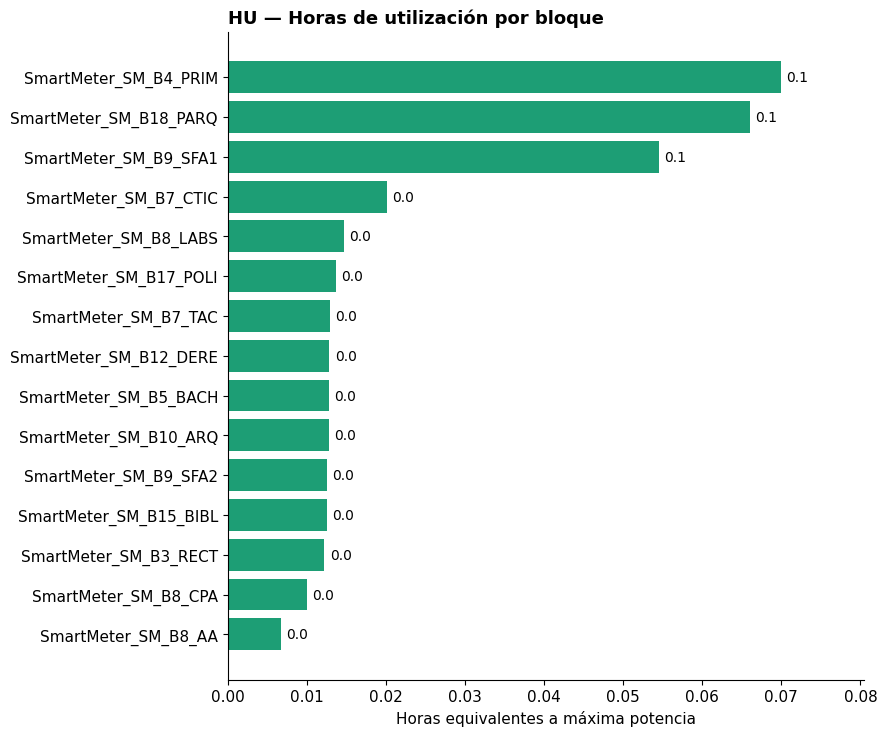

In [ ]:
# ── Celda 8: Indicador HU — Barras horizontales por bloque ──────────────────
hu_bloque = ind.groupby('entity_id')['HU_horas'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(hu_bloque))))
ax.barh(hu_bloque.index.astype(str), hu_bloque.values,
        color=C_TEAL, edgecolor='none')
for i, v in enumerate(hu_bloque.values):
    ax.text(v + hu_bloque.max() * 0.01, i, f'{v:.1f}', va='center', fontsize=10)
ax.set_xlim(0, hu_bloque.max() * 1.15)
ax.set_title('HU — Horas de utilización por bloque', loc='left')
ax.set_xlabel('Horas equivalentes a máxima potencia')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# ── Celda 9: Indicador CO₂ — Tres widgets Plotly ───────────────────
FACTOR_EMISION_CO2        = 9.7018e-8   # tCO₂e / Wh
ARBOLES_POR_TON_CO2       = 45          # árboles jóvenes por tCO₂e
TON_CO2_POR_VUELO_MDE_BOG = 0.18        # tCO₂e por trayecto MDE–BOG
TON_CO2_POR_VEHICULO_ANO  = 4.6         # tCO₂e por vehículo/año (IPCC)


def graficar_widget_1_co2(ind_df, ind_full=None):
    if ind_df.empty:
        return go.Figure()
    total     = float(ind_df['CO2_tCO2e'].sum())
    fecha_ini = ind_df['fecha'].min()
    fecha_fin = ind_df['fecha'].max()
    arboles   = int(total * ARBOLES_POR_TON_CO2)
    vuelos    = total / TON_CO2_POR_VUELO_MDE_BOG
    vehiculos = total / TON_CO2_POR_VEHICULO_ANO

    delta     = None
    total_ant = None
    ref_txt   = ''
    if ind_full is not None:
        n_dias  = (fecha_fin - fecha_ini).days + 1
        ant_fin = fecha_ini - pd.Timedelta(days=1)
        ant_ini = ant_fin  - pd.Timedelta(days=n_dias - 1)
        df_ant  = ind_full[(ind_full['fecha'] >= ant_ini) & (ind_full['fecha'] <= ant_fin)]
        if not df_ant.empty:
            total_ant = float(df_ant['CO2_tCO2e'].sum())
            delta     = total - total_ant
            ref_txt   = f'{ant_ini.strftime("%d %b")}–{ant_fin.strftime("%d %b")}'

    ind_kw = dict(
        mode='number+delta' if delta is not None else 'number',
        value=total,
        number=dict(font=dict(size=64, color='#2C2C2A'), valueformat=',.3f',
                    suffix=' tCO₂e'),
        domain=dict(x=[0.05, 0.95], y=[0.50, 1.0]),
    )
    if delta is not None:
        ind_kw['delta'] = dict(
            reference=float(total_ant), valueformat='+,.3f', relative=False,
            increasing=dict(color=C_AMBER), decreasing=dict(color=C_TEAL),
        )
    fig = go.Figure(go.Indicator(**ind_kw))
    fig.add_annotation(
        x=0.5, y=0.38, xref='paper', yref='paper', showarrow=False,
        text=f'Período: {fecha_ini.strftime("%d %b %Y")} – {fecha_fin.strftime("%d %b %Y")}',
        font=dict(size=13, color='#5F5E5A'), align='center',
    )
    fig.add_annotation(
        x=0.5, y=0.20, xref='paper', yref='paper', showarrow=False,
        text=(f'\U0001f333 {arboles:,} árboles jóvenes'
              f'&nbsp;&nbsp;&nbsp;'
              f'✈️ {vuelos:.0f} vuelos MDE–BOG'
              f'&nbsp;&nbsp;&nbsp;'
              f'\U0001f697 {vehiculos:.1f} vehículos/año'),
        font=dict(size=13, color='#5F5E5A'), align='center',
    )
    if delta is not None:
        flecha = '↑' if delta > 0 else '↓'
        fig.add_annotation(
            x=0.5, y=0.05, xref='paper', yref='paper', showarrow=False,
            text=f'{flecha} {abs(delta):,.3f} tCO₂e vs período anterior ({ref_txt})',
            font=dict(size=12, color=C_AMBER if delta > 0 else C_TEAL), align='center',
        )
    else:
        fig.add_annotation(
            x=0.5, y=0.05, xref='paper', yref='paper', showarrow=False,
            text='Sin período anterior para comparar',
            font=dict(size=12, color=C_GRAY),
        )
    fig.update_layout(
        title=dict(text='Huella de carbono del Ecocampus',
                   font=dict(size=13), x=0.5, xanchor='center'),
        plot_bgcolor='white', paper_bgcolor='white',
        height=310, margin=dict(t=40, b=10, l=20, r=20),
    )
    return fig


def graficar_widget_2_co2(ind_df):
    diario = ind_df.groupby('fecha')['CO2_tCO2e'].sum().sort_index()
    if diario.empty:
        return go.Figure()
    acum     = diario.cumsum()
    es_finde = diario.index.dayofweek >= 5
    laboral  = diario[~es_finde]
    finde    = diario[es_finde]

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.6, 0.4], vertical_spacing=0.08,
        subplot_titles=('Emisiones acumuladas', 'Emisiones diarias'),
    )
    fig.add_trace(go.Scatter(
        x=acum.index, y=acum.values, mode='lines',
        fill='tozeroy', fillcolor='rgba(239,159,39,0.25)',
        line=dict(color=C_AMBER, width=2),
        name='Acumulado (tCO₂e)',
    ), row=1, col=1)
    fig.add_trace(go.Bar(
        x=laboral.index, y=laboral.values,
        name='Día hábil (L–V)', marker_color=C_TEAL,
    ), row=2, col=1)
    fig.add_trace(go.Bar(
        x=finde.index, y=finde.values,
        name='Fin de semana (S–D)', marker_color=C_AMBER,
    ), row=2, col=1)
    fig.update_layout(
        title=dict(text='Evolución temporal de emisiones CO₂',
                   font=dict(size=13), x=0, xanchor='left'),
        plot_bgcolor='white', paper_bgcolor='white',
        height=480, margin=dict(t=60, b=40, l=70, r=20),
        legend=dict(orientation='h', yanchor='bottom', y=1.02,
                    xanchor='right', x=1, font=dict(size=11)),
        barmode='overlay',
    )
    fig.update_yaxes(title_text='tCO₂e acumuladas', gridcolor='#EEEEEE', row=1, col=1)
    fig.update_yaxes(title_text='tCO₂e/día',   gridcolor='#EEEEEE', row=2, col=1)
    fig.update_xaxes(gridcolor='#EEEEEE', row=2, col=1)
    return fig


def graficar_widget_3_co2(ind_df, area_por_bloque=None):
    totales = (ind_df
               .assign(bloque=ind_df['entity_id'].str.replace('SmartMeter_SM_', '', regex=False))
               .groupby('bloque')['CO2_tCO2e'].sum()
               .sort_values())
    if totales.empty:
        return go.Figure()

    if area_por_bloque:
        areas = {k.replace('SmartMeter_SM_', ''): v for k, v in area_por_bloque.items()}
        comun = [b for b in totales.index if b in areas]
        if comun:
            intens = pd.Series({b: totales[b] / areas[b] for b in comun}).sort_values()
            fig = go.Figure(go.Bar(
                x=intens.values, y=intens.index.tolist(),
                orientation='h',
                marker=dict(
                    color=intens.values, colorscale='YlOrBr',
                    colorbar=dict(title=dict(text='tCO₂e/m²', side='right')),
                    showscale=True,
                ),
                text=[f'{v:.5f}' for v in intens.values], textposition='outside',
            ))
            fig.update_layout(
                title=dict(text='Intensidad de carbono por bloque (tCO₂e/m²)',
                           font=dict(size=13), x=0, xanchor='left'),
                xaxis_title='tCO₂e/m²',
                plot_bgcolor='white', paper_bgcolor='white',
                height=max(280, 30 * len(intens) + 100),
                margin=dict(t=40, b=40, l=110, r=100),
                xaxis=dict(gridcolor='#EEEEEE'),
            )
            return fig

    fig = go.Figure(go.Bar(
        x=totales.values, y=totales.index.tolist(),
        orientation='h', marker_color=C_AMBER,
        text=[f'{v:.3f}' for v in totales.values], textposition='outside',
    ))
    fig.update_layout(
        title=dict(text='Emisiones CO₂ por bloque (tCO₂e totales)',
                   font=dict(size=13), x=0, xanchor='left'),
        xaxis_title='tCO₂e',
        plot_bgcolor='white', paper_bgcolor='white',
        height=max(280, 30 * len(totales) + 100),
        margin=dict(t=40, b=40, l=110, r=80),
        xaxis=dict(gridcolor='#EEEEEE'),
    )
    return fig


# ── Renderizar ────────────────────────────────────────────────────────────────────────────
area_por_bloque = None  # dict {entity_id: m²} pendiente de Planeación Física UPB

graficar_widget_1_co2(ind, ind_full=ind).show()
graficar_widget_2_co2(ind).show()
graficar_widget_3_co2(ind, area_por_bloque=area_por_bloque).show()
if area_por_bloque is None:
    print('Nota: intensidad de carbono (tCO₂e/m²) no disponible — datos de área pendientes de Planeación Física UPB.')


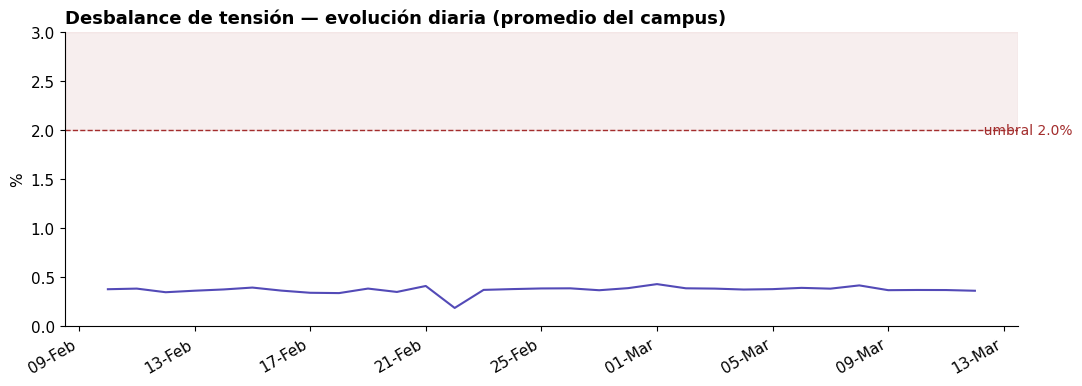

In [ ]:
# ── Celda 10: Indicador desbalance — Línea temporal con banda de umbral ─────
# Promedio por día sobre todos los bloques (vista global)
serie = ind.groupby('fecha')['desbalance_pct'].mean().sort_index()
UMBRAL = 2.0

fig, ax = plt.subplots(figsize=(11, 4))
ax.axhspan(UMBRAL, max(serie.max() * 1.1, UMBRAL * 1.5),
           color=C_RED, alpha=0.08)
ax.plot(serie.index, serie.values, color=C_PURPLE, linewidth=1.5)
ax.axhline(UMBRAL, color=C_RED, linestyle='--', linewidth=1)
ax.text(serie.index[-1], UMBRAL, f'  umbral {UMBRAL}%',
        va='center', fontsize=10, color=C_RED)
ax.set_ylim(0, max(serie.max() * 1.15, UMBRAL * 1.5))
ax.set_title('Desbalance de tensión — evolución diaria (promedio del campus)', loc='left')
ax.set_ylabel('%')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

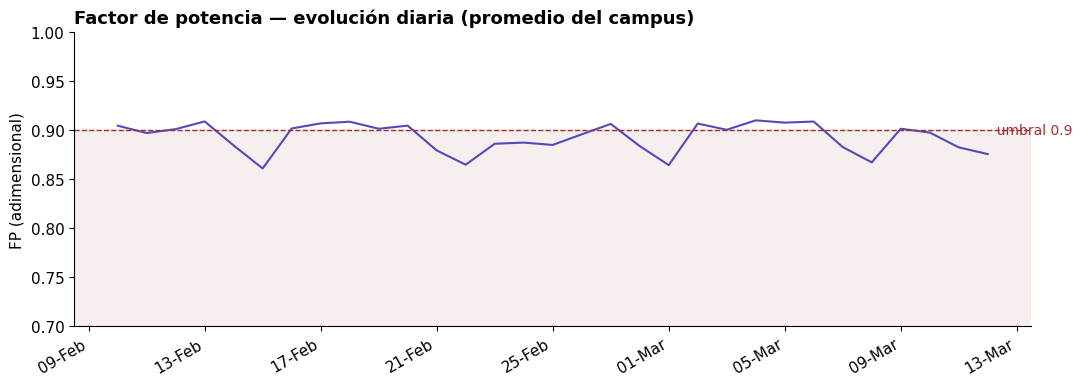

In [ ]:
# ── Celda 11: Indicador FP — Línea temporal con umbral CREG 0,9 ─────────────
serie = ind.groupby('fecha')['fp_promedio'].mean().sort_index()
UMBRAL_FP = 0.9

fig, ax = plt.subplots(figsize=(11, 4))
ax.axhspan(0, UMBRAL_FP, color=C_RED, alpha=0.08)
ax.plot(serie.index, serie.values, color=C_PURPLE, linewidth=1.5)
ax.axhline(UMBRAL_FP, color=C_RED, linestyle='--', linewidth=1)
ax.text(serie.index[-1], UMBRAL_FP, f'  umbral {UMBRAL_FP}',
        va='center', fontsize=10, color=C_RED)
ax.set_ylim(min(0.7, serie.min() * 0.98), 1.0)
ax.set_title('Factor de potencia — evolución diaria (promedio del campus)', loc='left')
ax.set_ylabel('FP (adimensional)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

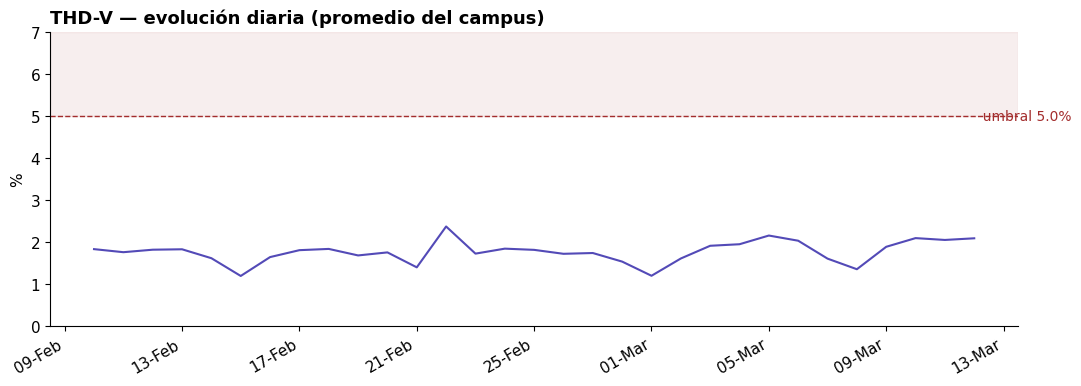

In [ ]:
# ── Celda 12: Indicador THD-V — Línea temporal con umbral IEEE 519 5% ───────
serie = ind.groupby('fecha')['thd_v_pct'].mean().sort_index()
UMBRAL_THD = 5.0

fig, ax = plt.subplots(figsize=(11, 4))
ax.axhspan(UMBRAL_THD, max(serie.max() * 1.15, UMBRAL_THD * 1.4),
           color=C_RED, alpha=0.08)
ax.plot(serie.index, serie.values, color=C_PURPLE, linewidth=1.5)
ax.axhline(UMBRAL_THD, color=C_RED, linestyle='--', linewidth=1)
ax.text(serie.index[-1], UMBRAL_THD, f'  umbral {UMBRAL_THD}%',
        va='center', fontsize=10, color=C_RED)
ax.set_ylim(0, max(serie.max() * 1.2, UMBRAL_THD * 1.4))
ax.set_title('THD-V — evolución diaria (promedio del campus)', loc='left')
ax.set_ylabel('%')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## KPIs

In [ ]:
# ── Celda 13: Carga KPIs ────────────────────────────────────────────────────
kpi = pd.read_csv(RUTA_KPIS)
kpi['fecha'] = pd.to_datetime(kpi['fecha'])
if 'KPI03_hora_pico' in kpi.columns:
    kpi['KPI03_hora_pico'] = pd.to_datetime(kpi['KPI03_hora_pico'], errors='coerce')

print(f'KPIs cargados: {len(kpi):,} filas · {kpi["entity_id"].nunique()} medidores')
kpi.head()

KPIs cargados: 465 filas · 15 medidores


,entity_id,fecha,KPI03_pico_kw,KPI03_hora_pico,KPI05_CO2_tCO2e,KPI08_LF,KPI09_f4_pct,KPI10_desbalance_pct,KPI11_fp,KPI12_thd_v_pct
0,SmartMeter_SM_B10_ARQ,2026-02-10,21044.316000,1970-01-01 00:00:00.000000009,0.029602,0.616194,20.846038,0.590018,0.948333,2.487369
1,SmartMeter_SM_B10_ARQ,2026-02-11,39388.084000,1970-01-01 00:00:00.000000014,0.044054,0.496221,20.220367,0.673316,0.925475,2.351624
2,SmartMeter_SM_B10_ARQ,2026-02-12,29041.240000,1970-01-01 00:00:00.000000007,0.043069,0.658580,39.404612,0.589177,0.932982,2.435472
3,SmartMeter_SM_B10_ARQ,2026-02-13,33282.408333,1970-01-01 00:00:00.000000015,0.028455,0.375208,20.426298,0.504226,0.936988,2.299417
4,SmartMeter_SM_B10_ARQ,2026-02-14,10266.029167,1970-01-01 00:00:00.000000008,0.014544,0.627169,31.155469,0.395151,0.922160,1.748917


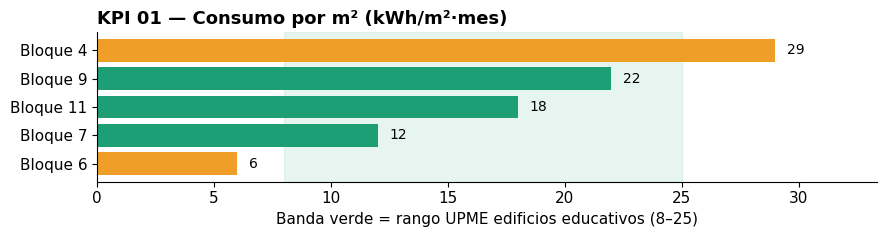

In [ ]:
# ── Celda 14: KPI 01 — Consumo por m² (barras con banda UPME) ───────────────
# NOTA: KPI 01 no aparece en kpis_diarios.csv porque depende de Área_bloque
# (parámetro institucional pendiente de Planeación Física UPB). Se ilustra con
# valores de referencia para que la visualización quede materializada.
RANGO_UPME = (8, 25)  # kWh/m²·mes para edificios educativos

# Ejemplo ilustrativo — reemplazar con cálculo real cuando llegue Área_bloque
ejemplo = pd.Series({
    'Bloque 6':  6,
    'Bloque 7':  12,
    'Bloque 11': 18,
    'Bloque 9':  22,
    'Bloque 4':  29,
}).sort_values()
colores = [C_AMBER if (v < RANGO_UPME[0] or v > RANGO_UPME[1]) else C_TEAL
           for v in ejemplo]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(ejemplo))))
ax.axvspan(RANGO_UPME[0], RANGO_UPME[1], color=C_TEAL, alpha=0.10)
ax.barh(ejemplo.index, ejemplo.values, color=colores, edgecolor='none')
for i, v in enumerate(ejemplo.values):
    ax.text(v + 0.5, i, f'{v}', va='center', fontsize=10)
ax.set_xlim(0, max(ejemplo.max() * 1.15, RANGO_UPME[1] * 1.2))
ax.set_title('KPI 01 — Consumo por m² (kWh/m²·mes)', loc='left')
ax.set_xlabel(f'Banda verde = rango UPME edificios educativos ({RANGO_UPME[0]}–{RANGO_UPME[1]})')
plt.tight_layout()
plt.show()

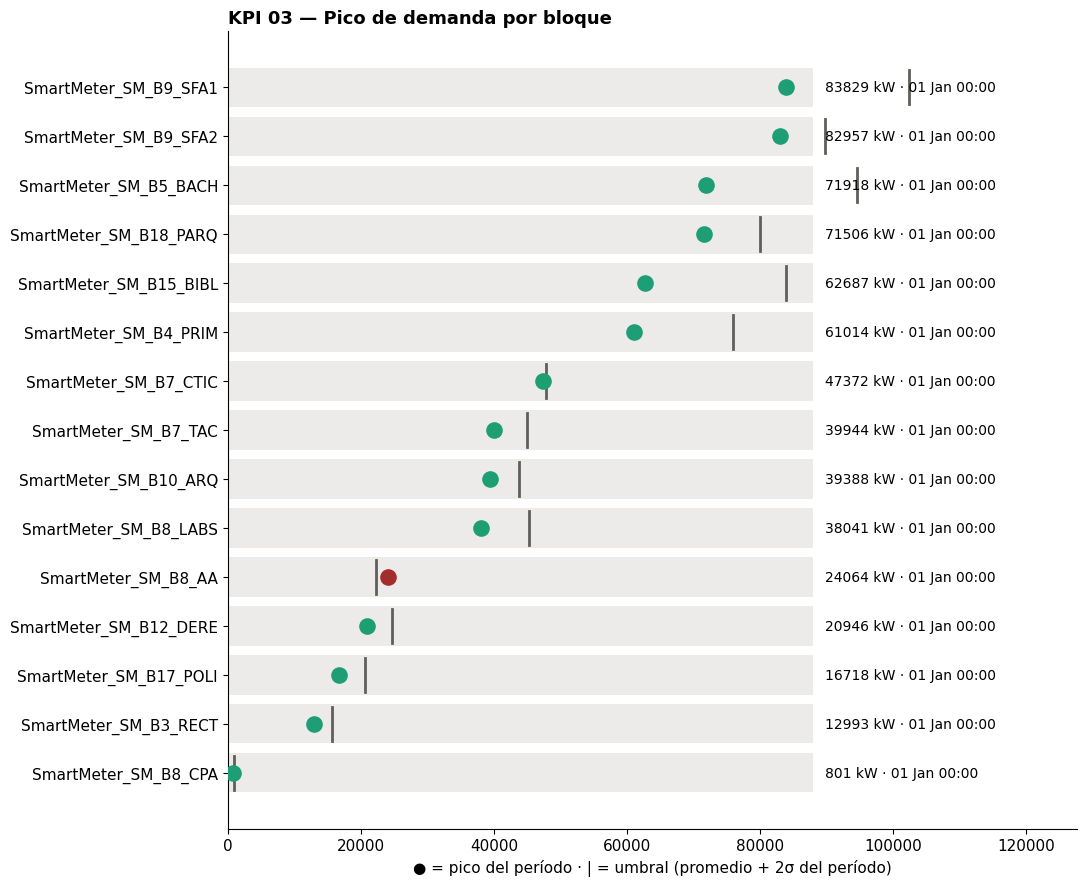

In [ ]:
# ── Celda 15: KPI 03 — Pico de demanda (bullet chart) ───────────────────────
# El umbral correcto es 'promedio + 1σ del año anterior' (línea base histórica).
# Como en kpis_diarios.csv solo hay un período corto, el umbral se aproxima
# usando promedio + 2σ de los picos diarios del mismo período: identifica
# bloques cuyo peor día se desvía mucho de su comportamiento típico.
# Cuando exista línea base histórica, reemplazar por: umbral = media_anterior + 1σ.
agg = kpi.groupby('entity_id').agg(
    pico=('KPI03_pico_kw', 'max'),
    media_pico=('KPI03_pico_kw', 'mean'),
    sigma_pico=('KPI03_pico_kw', 'std'),
)
agg['umbral'] = agg['media_pico'] + 2 * agg['sigma_pico'].fillna(0)

# Hora exacta del pico de cada bloque
idx_max = kpi.groupby('entity_id')['KPI03_pico_kw'].idxmax()
agg['hora_pico'] = kpi.loc[idx_max].set_index('entity_id')['KPI03_hora_pico']
agg = agg.sort_values('pico', ascending=True)

fig, ax = plt.subplots(figsize=(11, max(3, 0.6 * len(agg))))
x_max = agg['pico'].max() * 1.05
for i, (bloque, row) in enumerate(agg.iterrows()):
    # Carril gris de fondo (rango disponible)
    ax.barh(i, x_max, color=C_GRAY, alpha=0.25, edgecolor='none')
    # Marca de umbral (raya vertical)
    ax.plot([row['umbral'], row['umbral']], [i - 0.35, i + 0.35],
            color='#5F5E5A', linewidth=2)
    # Punto del pico (verde si cumple, rojo si supera)
    color_pt = C_TEAL if row['pico'] <= row['umbral'] else C_RED
    ax.scatter(row['pico'], i, color=color_pt, s=120, zorder=5)
    # Etiqueta con valor y fecha
    fecha_txt = (row['hora_pico'].strftime('%d %b %H:%M')
                 if pd.notna(row['hora_pico']) else '')
    ax.text(x_max * 1.02, i, f'{row["pico"]:.0f} kW · {fecha_txt}',
            va='center', fontsize=10)

ax.set_yticks(range(len(agg)))
ax.set_yticklabels(agg.index)
ax.set_xlim(0, x_max * 1.45)
ax.set_title('KPI 03 — Pico de demanda por bloque', loc='left')
ax.set_xlabel('● = pico del período · | = umbral (promedio + 2σ del período)')
plt.tight_layout()
plt.show()

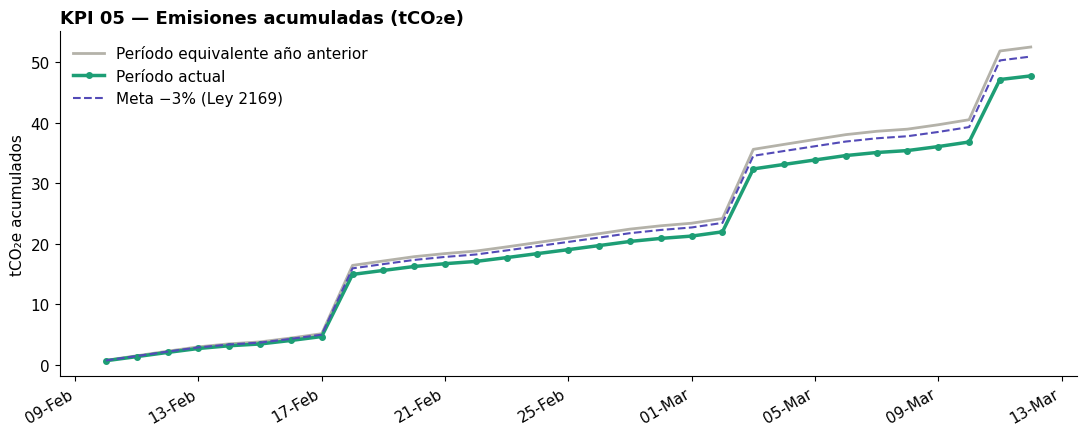

In [ ]:
# ── Celda 16: KPI 05 — Emisiones CO₂ acumuladas vs año anterior + meta ──────
# KPI 05 propuesto: línea acumulada año actual vs año anterior + meta -3%.
# El archivo solo contiene el período actual; el año anterior y la meta se
# simulan para que las tres series existan. Cuando exista la línea base real,
# reemplazar `anterior_acum` y `meta_acum` por las series institucionales.

actual_diario = (kpi.groupby('fecha')['KPI05_CO2_tCO2e'].sum()
                    .sort_index())
actual_acum = actual_diario.cumsum()

# Año anterior simulado (+10% del actual, mismo período desplazado un año)
anterior_acum = actual_acum * 1.10
anterior_acum.index = anterior_acum.index - pd.DateOffset(years=1)

# Meta: -3% sobre el año anterior
meta_acum = anterior_acum * 0.97
meta_acum.index = actual_acum.index  # comparable contra el actual
anterior_alineado = anterior_acum.copy()
anterior_alineado.index = actual_acum.index  # superponer en el mismo eje

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(anterior_alineado.index, anterior_alineado.values,
        color=C_GRAY, linewidth=2, label='Período equivalente año anterior')
ax.plot(actual_acum.index, actual_acum.values,
        color=C_TEAL, linewidth=2.5, marker='o', markersize=4,
        label='Período actual')
ax.plot(meta_acum.index, meta_acum.values,
        color=C_PURPLE, linewidth=1.5, linestyle='--',
        label='Meta −3% (Ley 2169)')
ax.set_title('KPI 05 — Emisiones acumuladas (tCO₂e)', loc='left')
ax.set_ylabel('tCO₂e acumulados')
ax.legend(frameon=False, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

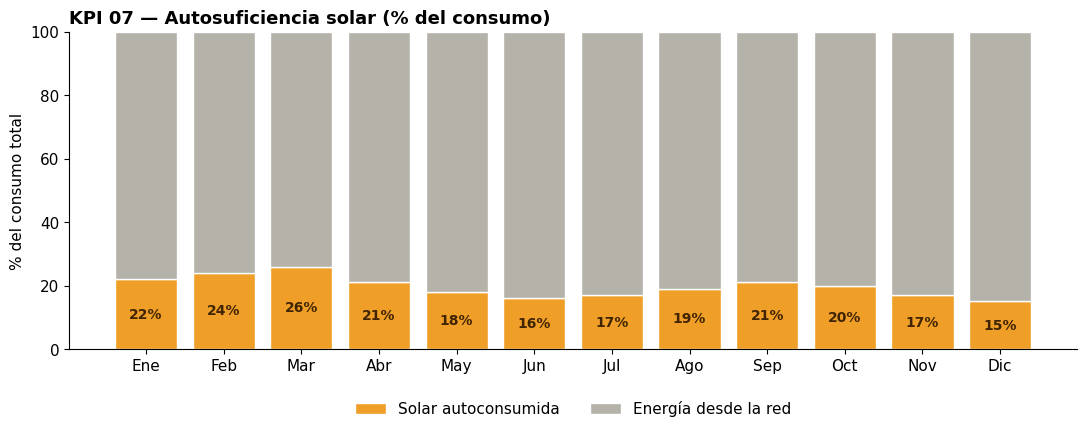

In [ ]:
# ── Celda 17: KPI 07 — Autosuficiencia solar (barras apiladas 100%) ─────────
# KPI 07 no aparece en kpis_diarios.csv (requiere energyproducedtoday del FV).
# Visualización ilustrativa con valores de referencia.

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
solar = np.array([22, 24, 26, 21, 18, 16, 17, 19, 21, 20, 17, 15])
red   = 100 - solar

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(meses, solar, color=C_AMBER, label='Solar autoconsumida', edgecolor='white')
ax.bar(meses, red, bottom=solar, color=C_GRAY, label='Energía desde la red',
       edgecolor='white')
for i, v in enumerate(solar):
    ax.text(i, v / 2, f'{v}%', ha='center', va='center',
            fontsize=10, color='#412402', fontweight='bold')

ax.set_ylim(0, 100)
ax.set_ylabel('% del consumo total')
ax.set_title('KPI 07 — Autosuficiencia solar (% del consumo)', loc='left')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
# ── Celda 18: KPI 08 — Load Factor (% de días en cumplimiento del umbral) ────
# El indicador LF (Celda 2) muestra el valor promedio por bloque.
# Este KPI muestra la gestión: ¿cuántos días cada bloque supera LF ≥ 0,65?
UMBRAL_LF = 0.65
cumplimiento_lf = (kpi.groupby('entity_id')
                   .apply(lambda g: (g['KPI08_LF'] >= UMBRAL_LF).mean() * 100)
                   .sort_values()
                   .rename('pct'))
colores = [C_TEAL if v >= 50 else C_AMBER for v in cumplimiento_lf]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(cumplimiento_lf))))
ax.barh(cumplimiento_lf.index.astype(str), cumplimiento_lf.values,
        color=colores, edgecolor='none')
for i, v in enumerate(cumplimiento_lf.values):
    ax.text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=10)
ax.set_xlim(0, 115)
ax.set_title('KPI 08 — % de días con LF ≥ 0,65 por bloque', loc='left')
ax.set_xlabel('% de días en cumplimiento del umbral (Papadopoulos et al., 2016)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Celda 19: KPI 09 — Índice de consumo nocturno (barras por bloque) ────────
# El heatmap diagnóstico ya está en la Celda 7 (indicador f₄). Aquí se
# muestra únicamente el resumen de gestión: cumplimiento de los umbrales de
# fracción de energía nocturna (Papadopoulos et al., 2016, ec. 7).
# f₄ KPI (%) ≠ f₄ indicador (adimensional): son métricas distintas.
UMBRAL_OBJETIVO = 10.0   # %
UMBRAL_ALERTA   = 20.0   # %

f4_bloque = (kpi.groupby('entity_id')['KPI09_f4_pct'].mean()
                .sort_values(ascending=False))

def _color_kpi09(v):
    if v > UMBRAL_ALERTA:  return C_RED
    if v > UMBRAL_OBJETIVO: return C_AMBER
    return C_TEAL

colores_b = [_color_kpi09(v) for v in f4_bloque]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(f4_bloque))))
ax.barh(f4_bloque.index.astype(str), f4_bloque.values,
        color=colores_b, edgecolor='none')
ax.axvline(UMBRAL_OBJETIVO, color=C_TEAL, linestyle='--', linewidth=1)
ax.axvline(UMBRAL_ALERTA,   color=C_RED,  linestyle='--', linewidth=1)
ax.text(UMBRAL_OBJETIVO, len(f4_bloque) - 0.3, f' objetivo {UMBRAL_OBJETIVO:.0f}%',
        ha='left', va='bottom', fontsize=9, color=C_TEAL)
ax.text(UMBRAL_ALERTA,   len(f4_bloque) - 0.3, f' alerta {UMBRAL_ALERTA:.0f}%',
        ha='left', va='bottom', fontsize=9, color=C_RED)
for i, v in enumerate(f4_bloque.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, max(f4_bloque.max() * 1.15, 25))
ax.set_title('KPI 09 — Índice de consumo nocturno por bloque', loc='left')
ax.set_xlabel('% energía 22:00–07:00 · Verde < 10% · Ámbar 10–20% · Rojo > 20%')
plt.tight_layout()
plt.show()

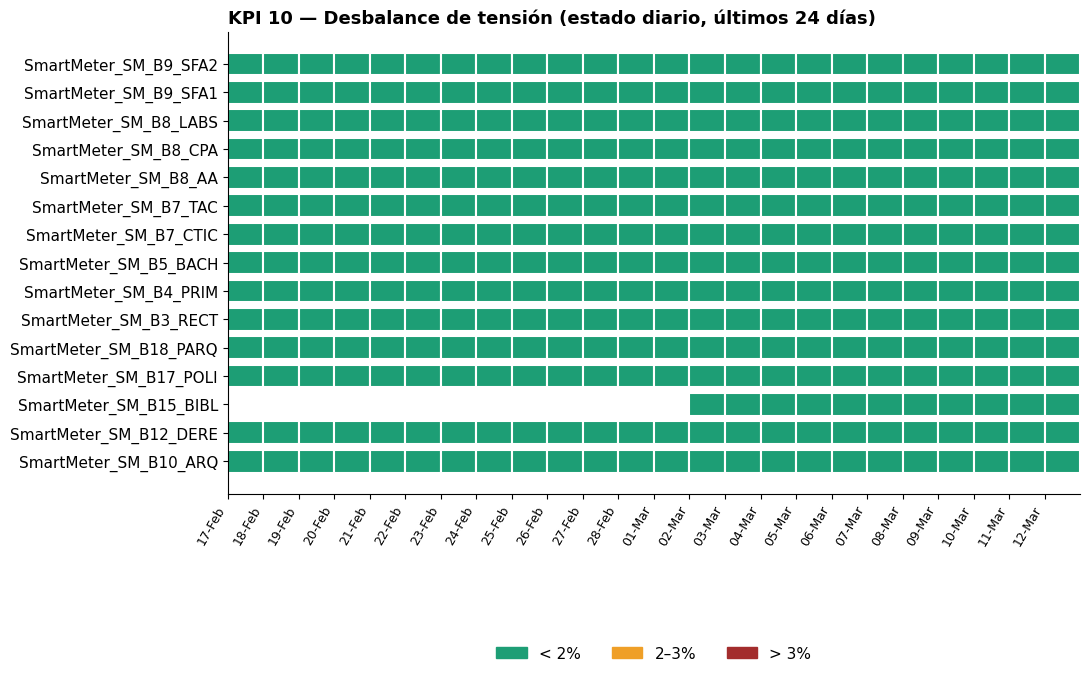

In [ ]:
# ── Celda 20: KPI 10 — Desbalance de tensión (tira de estado por hora) ──────
# Requiere granularidad horaria para representar la persistencia ≥3 h.
# El archivo diario solo da un valor por día; mostramos una tira por DÍA
# de los últimos N días, coloreada por estado del día.

ULTIMOS_DIAS = 24
pivot = (kpi.pivot_table(index='entity_id', columns='fecha',
                          values='KPI10_desbalance_pct', aggfunc='mean')
             .iloc[:, -ULTIMOS_DIAS:])

def color_db(v):
    if pd.isna(v): return '#FFFFFF'
    if v < 2:  return C_TEAL
    if v <= 3: return C_AMBER
    return C_RED

fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * len(pivot) + 1.5)))
for i, (bloque, fila) in enumerate(pivot.iterrows()):
    for j, v in enumerate(fila.values):
        ax.barh(i, 1, left=j, color=color_db(v), edgecolor='white', linewidth=1.5)

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index.astype(str))
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f.strftime('%d-%b') for f in pivot.columns],
                    rotation=60, ha='right', fontsize=9)
ax.set_xlim(0, len(pivot.columns))
ax.set_title(f'KPI 10 — Desbalance de tensión (estado diario, últimos {ULTIMOS_DIAS} días)',
             loc='left')

leyenda = [Patch(color=C_TEAL,  label='< 2%'),
           Patch(color=C_AMBER, label='2–3%'),
           Patch(color=C_RED,   label='> 3%')]
ax.legend(handles=leyenda, frameon=False, loc='upper center',
          bbox_to_anchor=(0.5, -0.30), ncol=3)
plt.subplots_adjust(bottom=0.32)
plt.show()

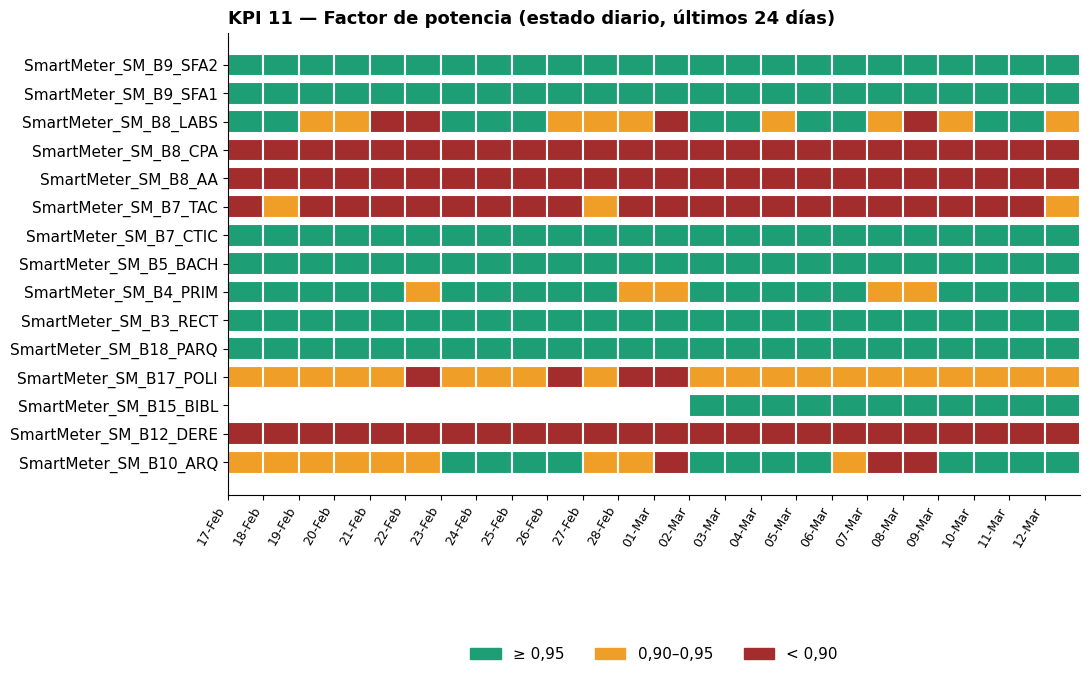

In [ ]:
# ── Celda 21: KPI 11 — Factor de potencia (tira de estado por día) ──────────
ULTIMOS_DIAS = 24
pivot = (kpi.pivot_table(index='entity_id', columns='fecha',
                          values='KPI11_fp', aggfunc='mean')
             .iloc[:, -ULTIMOS_DIAS:])

def color_fp(v):
    if pd.isna(v): return '#FFFFFF'
    if v >= 0.95: return C_TEAL
    if v >= 0.90: return C_AMBER
    return C_RED

fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * len(pivot) + 1.5)))
for i, (bloque, fila) in enumerate(pivot.iterrows()):
    for j, v in enumerate(fila.values):
        ax.barh(i, 1, left=j, color=color_fp(v), edgecolor='white', linewidth=1.5)

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index.astype(str))
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f.strftime('%d-%b') for f in pivot.columns],
                    rotation=60, ha='right', fontsize=9)
ax.set_xlim(0, len(pivot.columns))
ax.set_title(f'KPI 11 — Factor de potencia (estado diario, últimos {ULTIMOS_DIAS} días)',
             loc='left')

leyenda = [Patch(color=C_TEAL,  label='≥ 0,95'),
           Patch(color=C_AMBER, label='0,90–0,95'),
           Patch(color=C_RED,   label='< 0,90')]
ax.legend(handles=leyenda, frameon=False, loc='upper center',
          bbox_to_anchor=(0.5, -0.30), ncol=3)
plt.subplots_adjust(bottom=0.32)
plt.show()

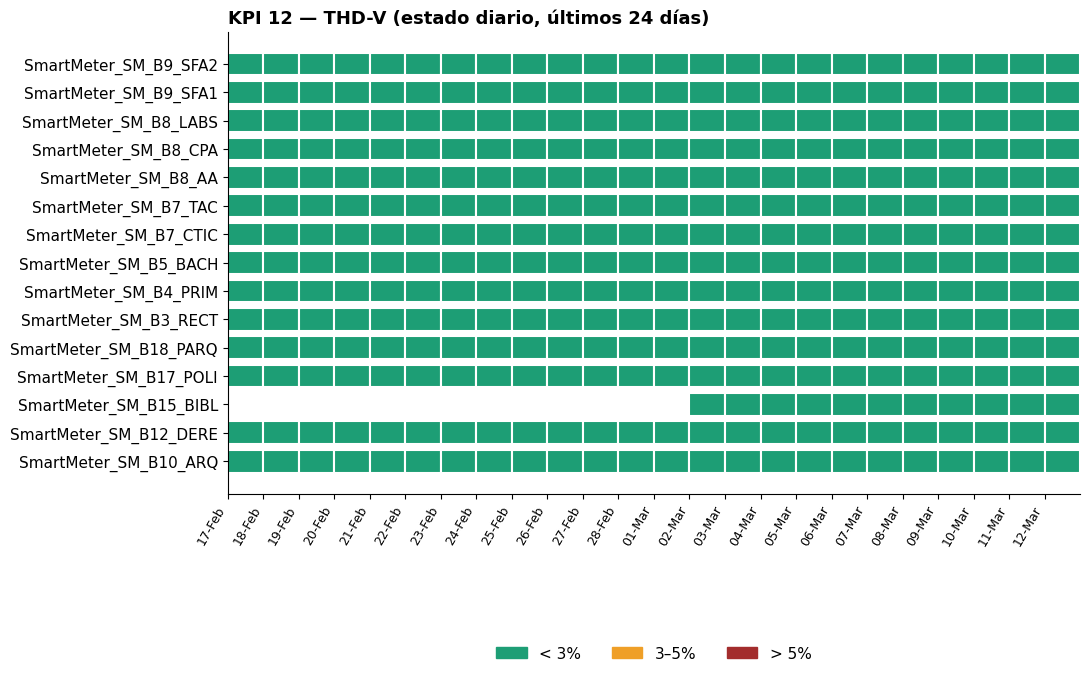

In [ ]:
# ── Celda 22: KPI 12 — THD-V (tira de estado por día) ───────────────────────
ULTIMOS_DIAS = 24
pivot = (kpi.pivot_table(index='entity_id', columns='fecha',
                          values='KPI12_thd_v_pct', aggfunc='mean')
             .iloc[:, -ULTIMOS_DIAS:])

def color_thd(v):
    if pd.isna(v): return '#FFFFFF'
    if v < 3:  return C_TEAL
    if v <= 5: return C_AMBER
    return C_RED

fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * len(pivot) + 1.5)))
for i, (bloque, fila) in enumerate(pivot.iterrows()):
    for j, v in enumerate(fila.values):
        ax.barh(i, 1, left=j, color=color_thd(v), edgecolor='white', linewidth=1.5)

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index.astype(str))
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f.strftime('%d-%b') for f in pivot.columns],
                    rotation=60, ha='right', fontsize=9)
ax.set_xlim(0, len(pivot.columns))
ax.set_title(f'KPI 12 — THD-V (estado diario, últimos {ULTIMOS_DIAS} días)',
             loc='left')

leyenda = [Patch(color=C_TEAL,  label='< 3%'),
           Patch(color=C_AMBER, label='3–5%'),
           Patch(color=C_RED,   label='> 5%')]
ax.legend(handles=leyenda, frameon=False, loc='upper center',
          bbox_to_anchor=(0.5, -0.30), ncol=3)
plt.subplots_adjust(bottom=0.32)
plt.show()